IPL Match & Delivery Data Analysis

Objective:
The objective of this project is to analyze IPL delivery data and identify insights related to player and team performance.

In [30]:
import pandas as pd

df = pd.read_csv("IPL_Analysis/deliveries.csv.zip", compression='zip')
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


## Dataset Information

In [32]:
df.shape

(150460, 21)

In [10]:
df.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150460 entries, 0 to 150459
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          150460 non-null  int64 
 1   inning            150460 non-null  int64 
 2   batting_team      150460 non-null  object
 3   bowling_team      150460 non-null  object
 4   over              150460 non-null  int64 
 5   ball              150460 non-null  int64 
 6   batsman           150460 non-null  object
 7   non_striker       150460 non-null  object
 8   bowler            150460 non-null  object
 9   is_super_over     150460 non-null  int64 
 10  wide_runs         150460 non-null  int64 
 11  bye_runs          150460 non-null  int64 
 12  legbye_runs       150460 non-null  int64 
 13  noball_runs       150460 non-null  int64 
 14  penalty_runs      150460 non-null  int64 
 15  batsman_runs      150460 non-null  int64 
 16  extra_runs        150460 non-null  int

In [ ]:
## Top 10 Batsmen Analysis

In [13]:
df.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissal_kind      143022
fielder             145091
dtype: int64

In [14]:
df.describe()

,match_id,inning,over,ball,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs
count,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000
mean,318.281317,1.482188,10.142649,3.616483,0.000538,0.037498,0.004885,0.022232,0.004340,0.000066,1.222445,0.069022,1.291466
std,182.955531,0.501768,5.674338,1.807698,0.023196,0.257398,0.114234,0.200104,0.072652,0.018229,1.594509,0.349667,1.583240
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,161.000000,1.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,319.000000,1.000000,10.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,476.000000,2.000000,15.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,636.000000,4.000000,20.000000,9.000000,1.000000,5.000000,4.000000,5.000000,5.000000,5.000000,6.000000,7.000000,7.000000


In [16]:
# Top 10 batsmen by runs

top_batsman = df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

top_batsman

batsman
SK Raina          4548
V Kohli           4423
RG Sharma         4207
G Gambhir         4132
DA Warner         4014
RV Uthappa        3778
CH Gayle          3651
S Dhawan          3561
MS Dhoni          3560
AB de Villiers    3486
Name: batsman_runs, dtype: int64

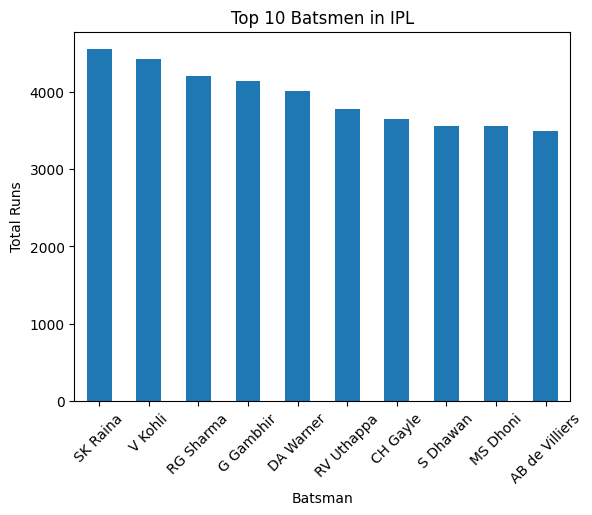

In [17]:
import matplotlib.pyplot as plt

top_batsman.plot(kind='bar')

plt.xlabel("Batsman")
plt.ylabel("Total Runs")
plt.title("Top 10 Batsmen in IPL")
plt.xticks(rotation=45)

plt.show()

## Top 10 Bowlers Analysis

In [19]:
top_bowler = df[df['dismissal_kind'].notnull()] \
.groupby('bowler')['dismissal_kind'] \
.count() \
.sort_values(ascending=False) \
.head(10)

top_bowler

bowler
SL Malinga         170
A Mishra           142
DJ Bravo           137
Harbhajan Singh    136
PP Chawla          133
R Vinay Kumar      125
A Nehra            121
Z Khan             119
B Kumar            117
R Ashwin           110
Name: dismissal_kind, dtype: int64

## Top 10 Bowlers Analysis

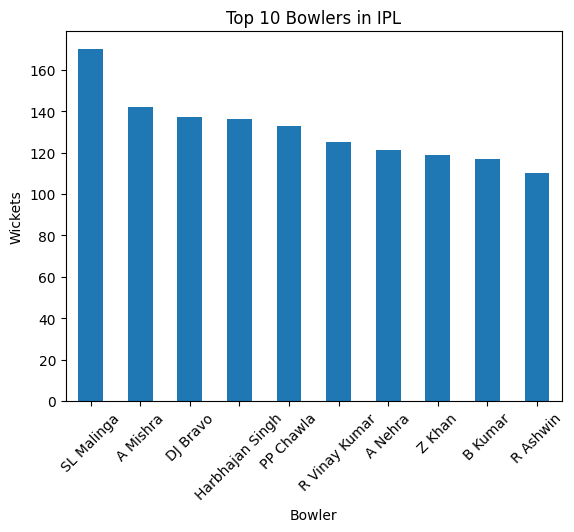

In [20]:
top_bowler.plot(kind='bar')

plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.title("Top 10 Bowlers in IPL")
plt.xticks(rotation=45)

plt.show()

In [ ]:
## Most Sixes Analysis

In [21]:
top_sixes = df[df['batsman_runs'] == 6] \
.groupby('batsman')['batsman_runs'] \
.count() \
.sort_values(ascending=False) \
.head(10)

top_sixes

batsman
CH Gayle          266
SK Raina          174
RG Sharma         173
DA Warner         160
V Kohli           160
AB de Villiers    158
MS Dhoni          156
YK Pathan         149
KA Pollard        148
Yuvraj Singh      141
Name: batsman_runs, dtype: int64

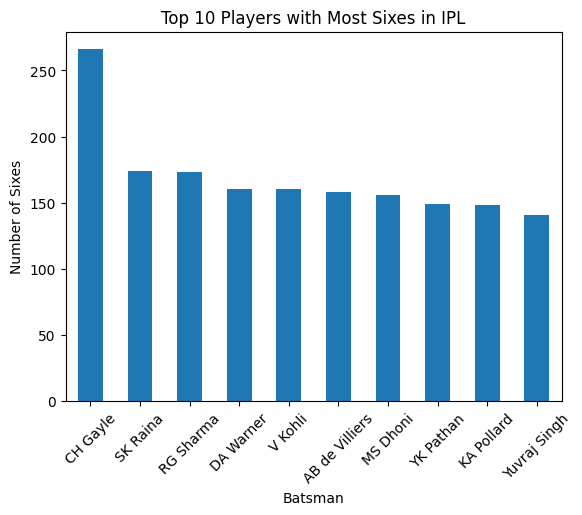

In [22]:

top_sixes.plot(kind='bar')

plt.xlabel("Batsman")
plt.ylabel("Number of Sixes")
plt.title("Top 10 Players with Most Sixes in IPL")
plt.xticks(rotation=45)

plt.show()

In [25]:
top_fours = df[df['batsman_runs'] == 4] \
.groupby('batsman')['batsman_runs'] \
.count() \
.sort_values(ascending=False) \
.head(10)

top_fours

batsman
G Gambhir     484
SK Raina      402
DA Warner     401
S Dhawan      401
V Kohli       384
RV Uthappa    377
RG Sharma     354
V Sehwag      334
AM Rahane     320
CH Gayle      297
Name: batsman_runs, dtype: int64

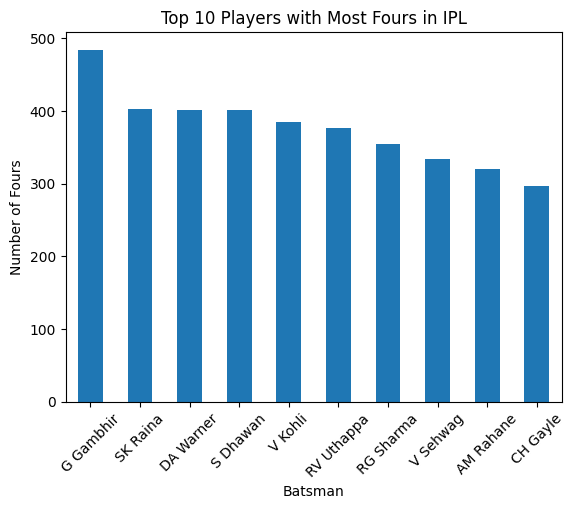

In [26]:
top_fours.plot(kind='bar')

plt.xlabel("Batsman")
plt.ylabel("Number of Fours")
plt.title("Top 10 Players with Most Fours in IPL")
plt.xticks(rotation=45)

plt.show()

In [27]:
team_runs = df.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)

team_runs

batting_team
Mumbai Indians                 24521
Royal Challengers Bangalore    23436
Kings XI Punjab                23068
Kolkata Knight Riders          21965
Delhi Daredevils               21953
Chennai Super Kings            20899
Rajasthan Royals               17703
Sunrisers Hyderabad            11652
Deccan Chargers                11463
Pune Warriors                   6358
Gujarat Lions                   4862
Rising Pune Supergiant          2470
Rising Pune Supergiants         2063
Kochi Tuskers Kerala            1901
Name: total_runs, dtype: int64

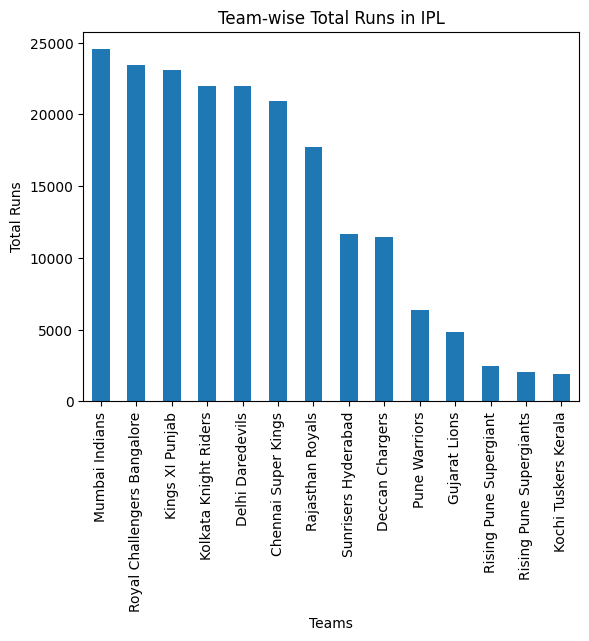

In [28]:
team_runs.plot(kind='bar')

plt.xlabel("Teams")
plt.ylabel("Total Runs")
plt.title("Team-wise Total Runs in IPL")
plt.xticks(rotation=90)

plt.show()

## Insights

• Top players by runs were identified  
• Top wicket-taking bowlers were analyzed  
• Team performance trends were analyzed  
• Most fours and sixes were identified

## Conclusion

This project analyzed IPL delivery data using Python and Pandas. Multiple visualizations were created to identify top-performing players and team trends. The analysis helped extract meaningful insights from a large dataset.